# Diabetes Health Indicators — Exploratory Data Analysis

## BRFSS 2015 Diabetes Health Indicators Dataset

**Student:** Sydney Bailey, Wolfgang, Harvey, Nashita 
**Course:** Intro to AI
**Date:** September 2026

# 1. Business Understanding

## 1.1 Purpose of the Dataset

The purpose of this dataset is to better understand the relationship between lifestyle, health conditions, demographic characteristics, and diabetes in the United States.

The data comes from the Behavioral Risk Factor Surveillance System (BRFSS) and contains information about health behaviors, health conditions, access to healthcare, and demographic characteristics reported by individuals.

The dataset is useful because diabetes is an important public health concern. Understanding which characteristics are associated with diabetes can help identify populations that may have a higher risk.

The primary question for this analysis is:

> **Which health, lifestyle, and demographic characteristics are most strongly associated with diabetes and prediabetes?**

A secondary goal is to determine whether these characteristics can be used to build a machine-learning model that accurately predicts an individual's diabetes status.

## 1.2 Defining and Measuring the Outcomes

The primary outcome variable is `Diabetes_012`.

This variable contains three classifications:

| Value | Meaning |
|---:|---|
| 0 | No diabetes |
| 1 | Prediabetes |
| 2 | Diabetes |

The outcome of this analysis will be measured by determining which features are most useful for distinguishing between these three groups.

Useful knowledge will be considered to have been discovered if the analysis identifies meaningful relationships between diabetes status and variables such as:

- High blood pressure
- High cholesterol
- BMI
- Age
- General health
- Physical activity
- Smoking
- Heart disease
- Stroke
- Physical health
- Mental health
- Income
- Education

For example, if individuals with high blood pressure consistently have a higher rate of diabetes than individuals without high blood pressure, this would represent an interesting relationship worth investigating.

## 1.3 Measuring Prediction Effectiveness

Because `Diabetes_012` is a classification problem, classification metrics will be used to evaluate future prediction algorithms.

### Accuracy

Accuracy measures the percentage of predictions that are correct.

Accuracy is useful as a general measure, but it can be misleading if the classes are imbalanced.

### Precision

Precision measures how many observations predicted to belong to a particular class actually belong to that class.

### Recall

Recall measures how many of the actual cases belonging to a class were correctly identified by the model.

### F1-Score

The F1-score combines precision and recall into a single metric. It is particularly useful when the dataset contains imbalanced classes.

### ROC-AUC

ROC-AUC measures how well a model can distinguish between classes across different classification thresholds.

### MAE, MSE, RMSE, and MAPE

MAE, MSE, RMSE, and MAPE are primarily regression metrics, so they will not be the primary metrics for this classification problem.

For this project, Accuracy, Precision, Recall, F1-score, and ROC-AUC will be more appropriate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools for later analysis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Your dataset is already loaded into this variable
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015 (1).csv")

print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully.
Number of rows: 253,680
Number of columns: 22


# 2. Data Understanding

The dataset contains health, lifestyle, healthcare access, and demographic variables that may be associated with diabetes status.

The target variable is `Diabetes_012`.

The remaining variables are predictors/features that may help explain differences between individuals with no diabetes, prediabetes, and diabetes.

In [3]:
df.head()
df.tail()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.00,1.00,1.00,1.00,45.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,3.00,0.00,5.00,0.00,1.00,5.00,6.00,7.00
253676,2.00,1.00,1.00,1.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,4.00,0.00,0.00,1.00,0.00,11.00,2.00,4.00
253677,0.00,0.00,0.00,1.00,28.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,2.00,5.00,2.00
253678,0.00,1.00,0.00,1.00,23.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,3.00,0.00,0.00,0.00,1.00,7.00,5.00,1.00
253679,2.00,1.00,1.00,1.00,25.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,0.00,9.00,6.00,2.00


In [4]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 253,680
Number of columns: 22


In [5]:
df.columns.tolist()

['Diabetes_012',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

## 2.1 Attribute Descriptions

| Attribute | Type | Description |
|---|---|---|
| `Diabetes_012` | Categorical / Integer | Target variable. 0 = no diabetes, 1 = prediabetes, 2 = diabetes |
| `HighBP` | Binary | High blood pressure. 0 = no, 1 = yes |
| `HighChol` | Binary | High cholesterol. 0 = no, 1 = yes |
| `CholCheck` | Binary | Cholesterol check within the past 5 years. 0 = no, 1 = yes |
| `BMI` | Integer | Body Mass Index |
| `Smoker` | Binary | Smoked at least 100 cigarettes during lifetime. 0 = no, 1 = yes |
| `Stroke` | Binary | Has ever been told they had a stroke. 0 = no, 1 = yes |
| `HeartDiseaseorAttack` | Binary | History of coronary heart disease or myocardial infarction. 0 = no, 1 = yes |
| `PhysActivity` | Binary | Physical activity during the past 30 days, excluding job-related activity. 0 = no, 1 = yes |
| `Fruits` | Binary | Consumes fruit at least once per day. 0 = no, 1 = yes |
| `Veggies` | Binary | Consumes vegetables at least once per day. 0 = no, 1 = yes |
| `HvyAlcoholConsump` | Binary | Heavy alcohol consumption. 0 = no, 1 = yes |
| `AnyHealthcare` | Binary | Has some form of healthcare coverage. 0 = no, 1 = yes |
| `NoDocbcCost` | Binary | Needed medical care but could not afford it. 0 = no, 1 = yes |
| `GenHlth` | Ordinal Integer | General health rating. 1 = excellent through 5 = poor |
| `MentHlth` | Integer | Number of days during the previous 30 days when mental health was not good |
| `PhysHlth` | Integer | Number of days during the previous 30 days when physical health was not good |
| `DiffWalk` | Binary | Serious difficulty walking or climbing stairs. 0 = no, 1 = yes |
| `Sex` | Binary | Sex. 0 = female, 1 = male |
| `Age` | Ordinal Integer | Age category from 1 = 18–24 through 13 = 80 or older |
| `Education` | Ordinal Integer | Education level from 1 = lowest education through 6 = college graduate |
| `Income` | Ordinal Integer | Income category from 1 = less than $10,000 through 8 = $75,000 or more |

### Measurement Scales

Not all integer variables should be treated as continuous numerical measurements.

For example:

- `Age` is an ordinal category, not an exact age.
- `Education` is an ordinal category.
- `Income` is an ordinal category.
- `GenHlth` is an ordinal health rating.
- `Diabetes_012` represents categories rather than a continuous numerical measurement.

This distinction is important when selecting statistical methods and interpreting correlations.

# 3. Data Quality

## 3.1 Missing Values

Missing values need to be identified before performing statistical analysis or machine learning.

If missing values are present, they need to be investigated and handled appropriately rather than automatically replacing them with arbitrary values.

In [7]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage Missing": (missing_values / len(df)) * 100
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage Missing
Diabetes_012,0,0.00
HighBP,0,0.00
HighChol,0,0.00
CholCheck,0,0.00
BMI,0,0.00
Smoker,0,0.00
Stroke,0,0.00
HeartDiseaseorAttack,0,0.00
PhysActivity,0,0.00
Fruits,0,0.00


## 3.2 Duplicate Data

Duplicate rows should be investigated before removing them.

A duplicate row is not necessarily a mistake because two different survey respondents could potentially have identical responses to every variable in the dataset.

Therefore, duplicate observations should not automatically be deleted without understanding how the dataset was collected.

In [8]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")
print(
    f"Percentage of duplicate rows: "
    f"{(duplicate_count / len(df)) * 100:.2f}%"
)

Number of duplicate rows: 23,899
Percentage of duplicate rows: 9.42%


# 4. Descriptive Statistics

Descriptive statistics provide an overview of the distributions of the variables.

The statistics include:

- Count
- Mean
- Standard deviation
- Minimum
- 25th percentile
- Median
- 75th percentile
- Maximum

These statistics help identify the center, spread, and possible unusual values in the dataset.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.00,0.30,0.70,0.00,0.00,0.00,0.00,2.00
HighBP,253680.00,0.43,0.49,0.00,0.00,0.00,1.00,1.00
HighChol,253680.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
CholCheck,253680.00,0.96,0.19,0.00,1.00,1.00,1.00,1.00
BMI,253680.00,28.38,6.61,12.00,24.00,27.00,31.00,98.00
Smoker,253680.00,0.44,0.50,0.00,0.00,0.00,1.00,1.00
Stroke,253680.00,0.04,0.20,0.00,0.00,0.00,0.00,1.00
HeartDiseaseorAttack,253680.00,0.09,0.29,0.00,0.00,0.00,0.00,1.00
PhysActivity,253680.00,0.76,0.43,0.00,1.00,1.00,1.00,1.00
Fruits,253680.00,0.63,0.48,0.00,0.00,1.00,1.00,1.00


In [10]:
important_variables = [
    "BMI",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Education",
    "Income"
]

df[important_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,253680.00,28.38,6.61,12.00,24.00,27.00,31.00,98.00
GenHlth,253680.00,2.51,1.07,1.00,2.00,2.00,3.00,5.00
MentHlth,253680.00,3.18,7.41,0.00,0.00,0.00,2.00,30.00
PhysHlth,253680.00,4.24,8.72,0.00,0.00,0.00,3.00,30.00
Age,253680.00,8.03,3.05,1.00,6.00,8.00,10.00,13.00
Education,253680.00,5.05,0.99,1.00,4.00,5.00,6.00,6.00
Income,253680.00,6.05,2.07,1.00,5.00,7.00,8.00,8.00


# 5. Target Variable — Diabetes Status

The target variable is `Diabetes_012`.

It contains three categories:

- `0` = No Diabetes
- `1` = Prediabetes
- `2` = Diabetes

Examining the distribution of the target is important because an imbalanced target can affect the performance and interpretation of machine-learning models.

In [11]:
diabetes_counts = df["Diabetes_012"].value_counts().sort_index()

diabetes_counts

Diabetes_012
0.00    213703
1.00      4631
2.00     35346
Name: count, dtype: int64

In [12]:
target_distribution = (
    df["Diabetes_012"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_distribution

Diabetes_012
0.00   84.24
1.00    1.83
2.00   13.93
Name: proportion, dtype: float64

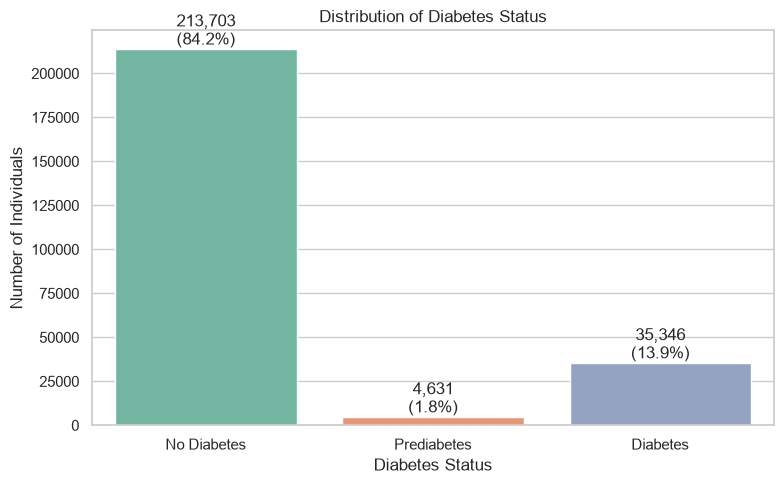

In [13]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Diabetes_012",
    hue="Diabetes_012",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Individuals")

plt.xticks(
    [0, 1, 2],
    ["No Diabetes", "Prediabetes", "Diabetes"]
)

total = len(df)

for i, count in enumerate(diabetes_counts):
    percentage = count / total * 100
    
    ax.text(
        i,
        count,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Interpretation

The target distribution shows how many observations belong to each diabetes category.

This chart is important because it allows us to determine whether the dataset is balanced across the three target classes.

If one category contains substantially more observations than the others, the dataset is considered imbalanced. In that situation, accuracy alone may not provide a complete picture of model performance.

For future predictive modeling, precision, recall, F1-score, and the confusion matrix should therefore be examined in addition to accuracy.

# 6. Binary Health Indicators

Many of the variables in the dataset are binary health indicators.

A value of `0` generally represents "No" and a value of `1` generally represents "Yes."

These variables allow us to compare health and lifestyle characteristics between different groups of respondents.

In [14]:
binary_columns = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

print("Binary variables:")
print(binary_columns)

Binary variables:
['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']


In [15]:
binary_summary = pd.DataFrame()

for col in binary_columns:
    binary_summary[col] = df[col].value_counts(normalize=True)

binary_summary.T

HighBP,0.00,1.00
HighBP,0.57,0.43
HighChol,0.58,0.42
CholCheck,0.04,0.96
Smoker,0.56,0.44
Stroke,0.96,0.04
HeartDiseaseorAttack,0.91,0.09
PhysActivity,0.24,0.76
Fruits,0.37,0.63
Veggies,0.19,0.81
HvyAlcoholConsump,0.94,0.06


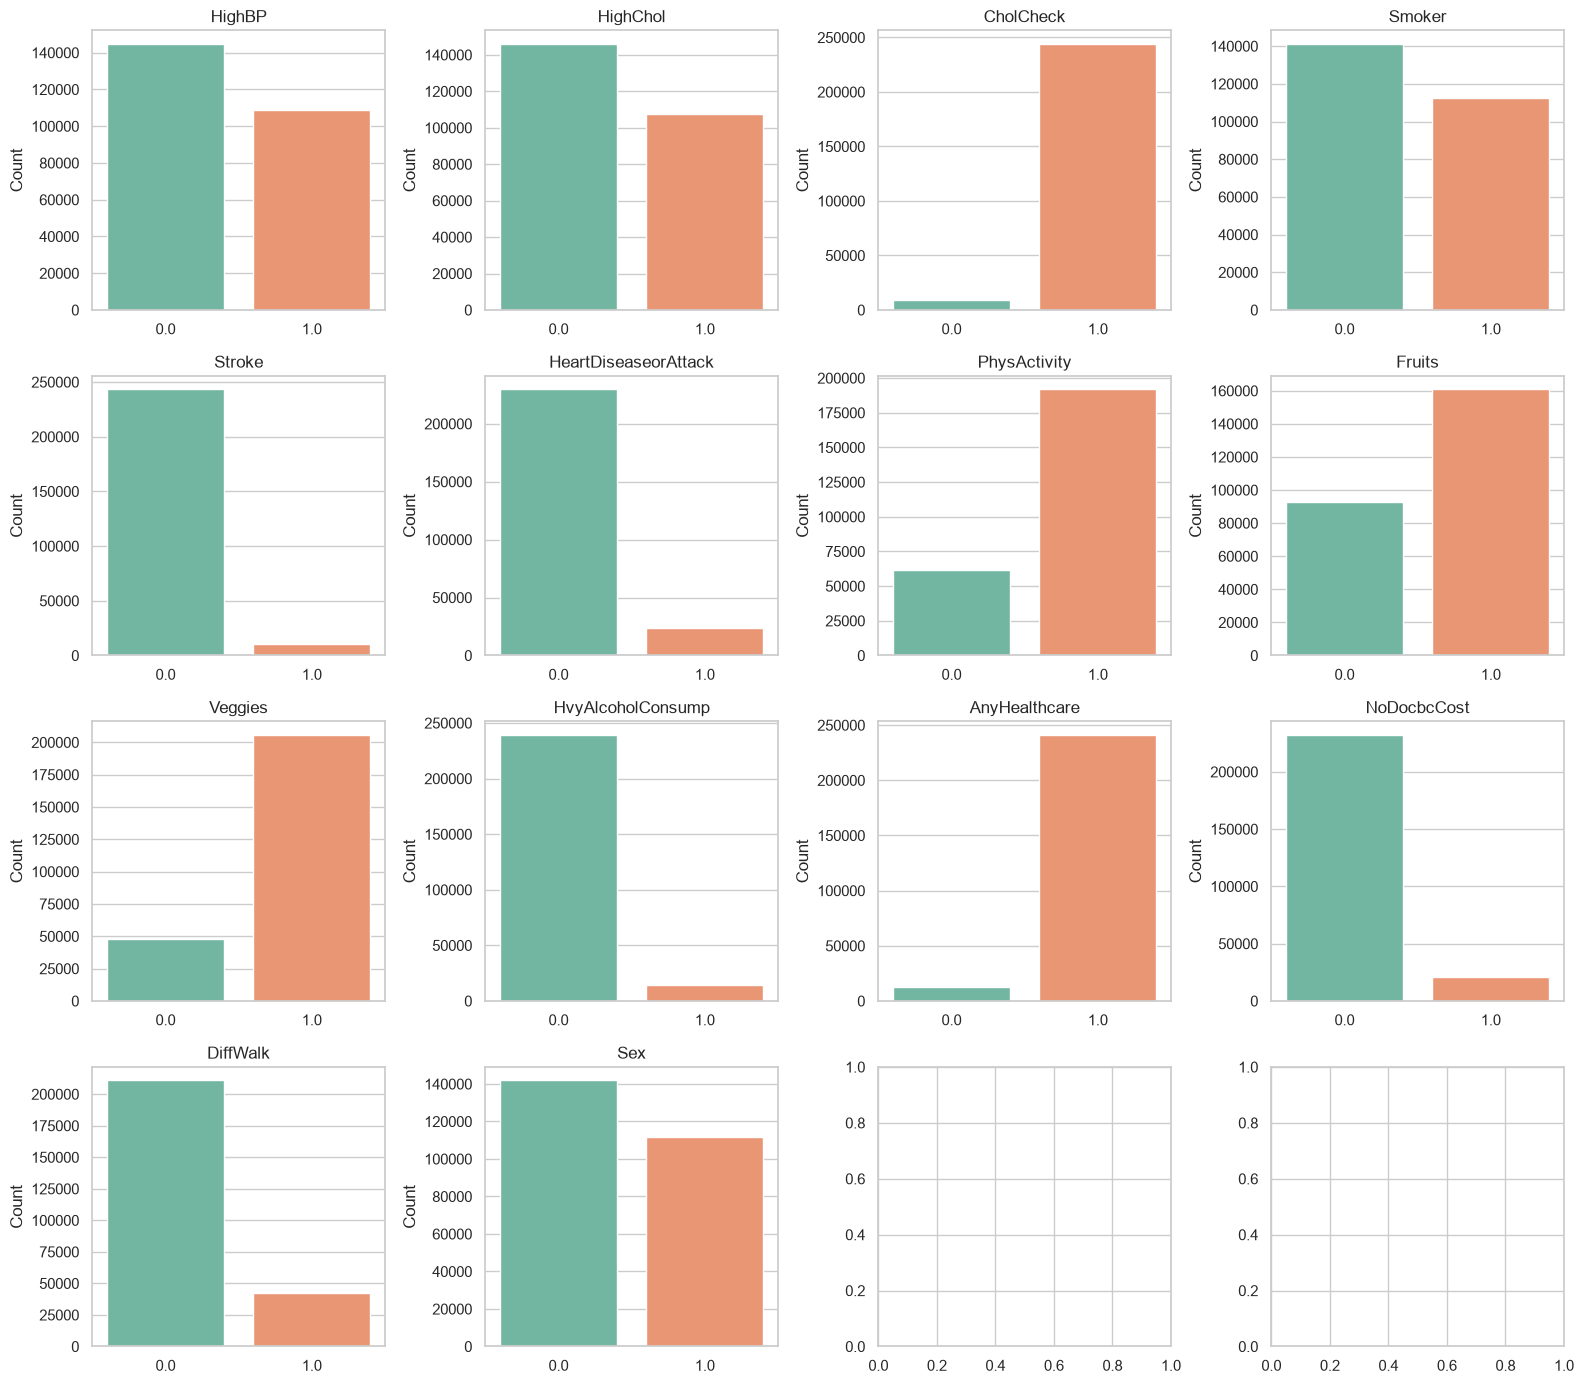

In [16]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(16, 14)
)

axes = axes.flatten()

for i, col in enumerate(binary_columns):
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        ax=axes[i],
        palette="Set2",
        legend=False
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

# 7. BMI Analysis

BMI is one of the most important numerical health variables in the dataset.

A histogram is appropriate for BMI because it allows us to examine the distribution, center, spread, and possible extreme values.

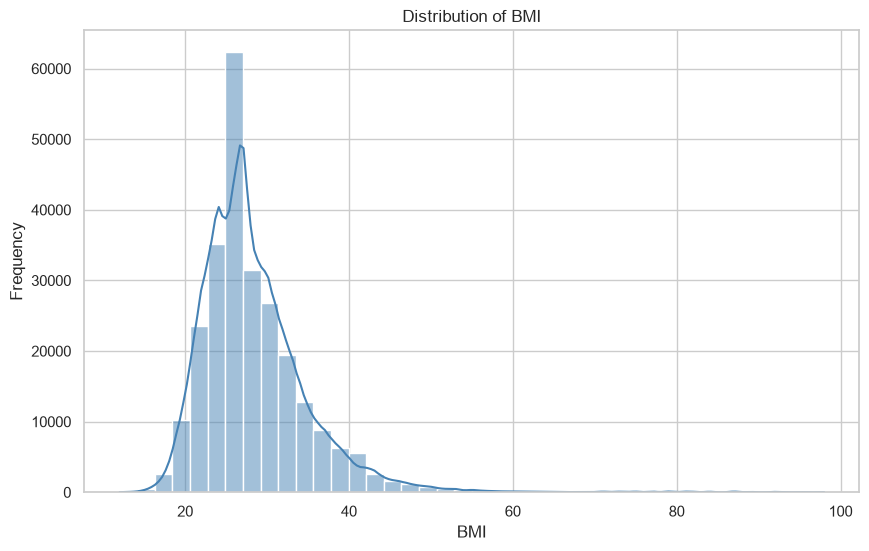

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="BMI",
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

In [18]:
df["BMI"].describe()

count   253680.00
mean        28.38
std          6.61
min         12.00
25%         24.00
50%         27.00
75%         31.00
max         98.00
Name: BMI, dtype: float64

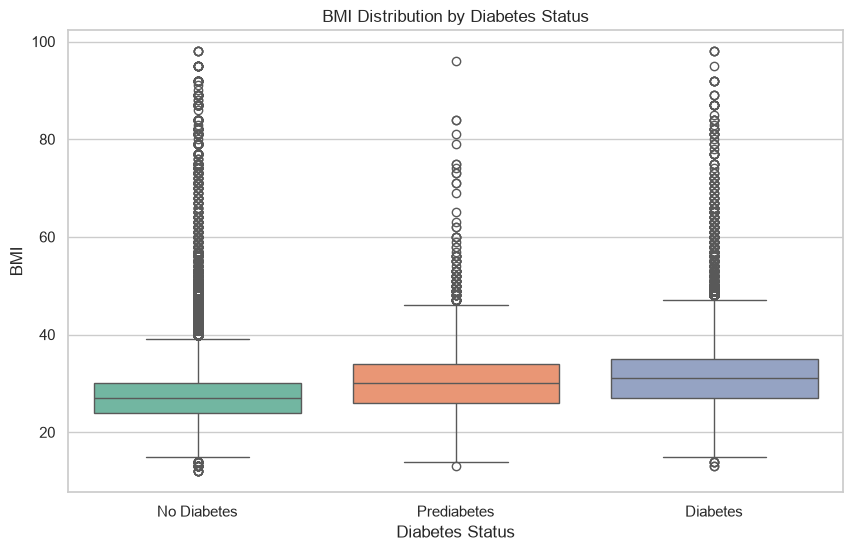

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Diabetes_012",
    y="BMI",
    hue="Diabetes_012",
    palette="Set2",
    legend=False
)

plt.title("BMI Distribution by Diabetes Status")

plt.xlabel("Diabetes Status")
plt.ylabel("BMI")

plt.xticks(
    [0, 1, 2],
    ["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.show()

## Interpretation

The box plot allows us to compare BMI distributions across the three diabetes categories.

The median, spread, and extreme values can be compared between groups.

If the diabetes group has a higher median BMI than the no-diabetes group, this would indicate an association between BMI and diabetes status.

This relationship does not establish causation, but it may indicate that BMI could be useful in a predictive model.

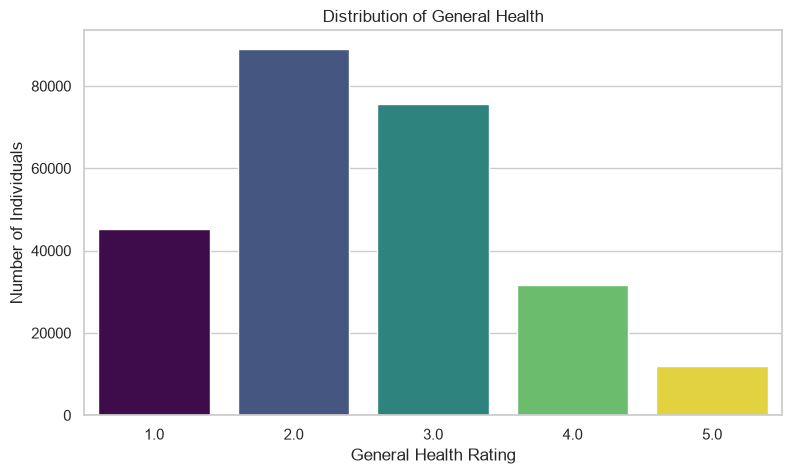

In [20]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="GenHlth",
    hue="GenHlth",
    palette="viridis",
    legend=False
)

plt.title("Distribution of General Health")
plt.xlabel("General Health Rating")
plt.ylabel("Number of Individuals")

plt.show()

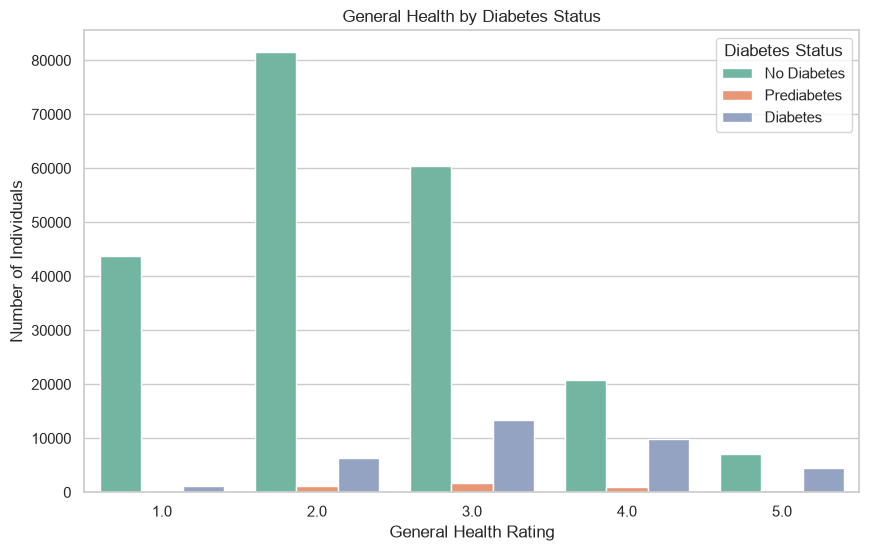

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="GenHlth",
    hue="Diabetes_012",
    palette="Set2"
)

plt.title("General Health by Diabetes Status")
plt.xlabel("General Health Rating")
plt.ylabel("Number of Individuals")

plt.legend(
    title="Diabetes Status",
    labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.show()

## Interpretation

`GenHlth` is an ordinal variable ranging from 1 = excellent health to 5 = poor health.

The grouped bar chart allows us to compare diabetes status across the different general health categories.

If poorer general health categories contain a greater proportion of respondents with diabetes, this would suggest that self-reported general health is an important feature to investigate further.

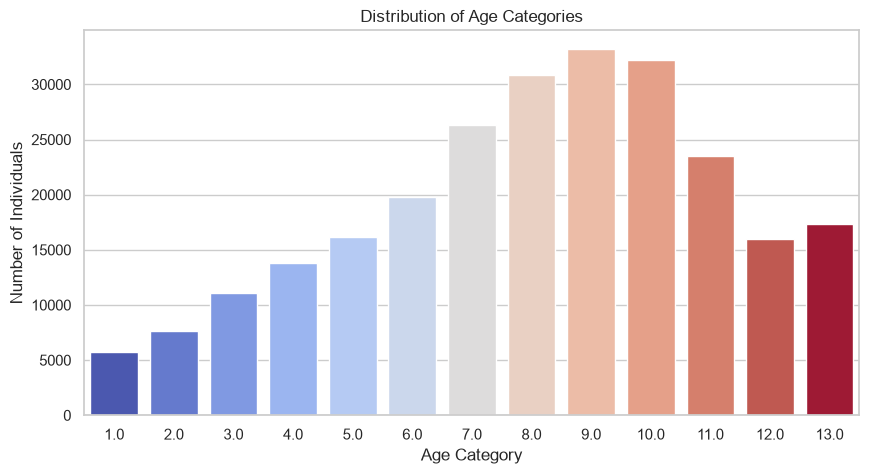

In [22]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Age",
    hue="Age",
    palette="coolwarm",
    legend=False
)

plt.title("Distribution of Age Categories")
plt.xlabel("Age Category")
plt.ylabel("Number of Individuals")

plt.show()

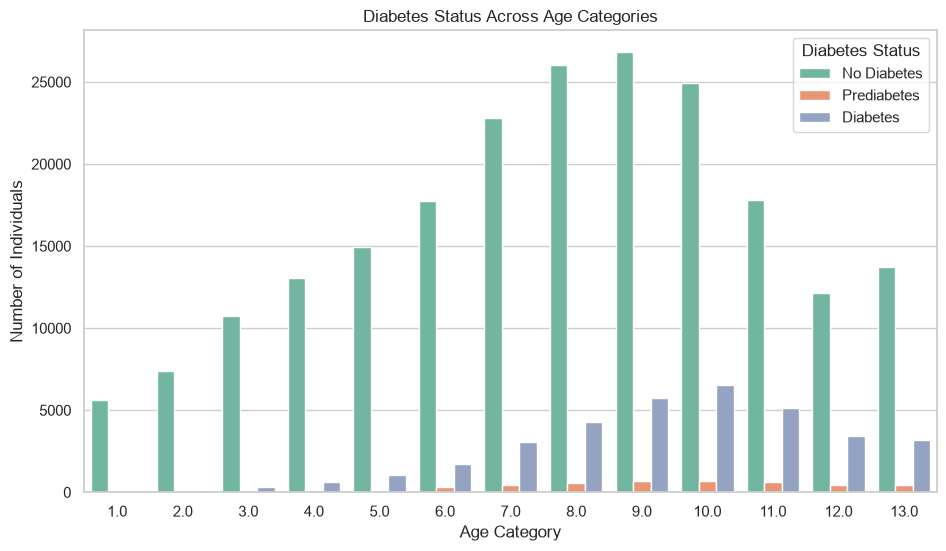

In [23]:
plt.figure(figsize=(11, 6))

sns.countplot(
    data=df,
    x="Age",
    hue="Diabetes_012",
    palette="Set2"
)

plt.title("Diabetes Status Across Age Categories")
plt.xlabel("Age Category")
plt.ylabel("Number of Individuals")

plt.legend(
    title="Diabetes Status",
    labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.show()

## Interpretation

Age is represented by categories rather than exact ages.

The chart allows us to determine whether the distribution of diabetes status changes across age categories.

Age is potentially important because diabetes may be more common in some age groups than others.

Because `Age` is ordinal rather than continuous, the categories should not be interpreted as exact numerical ages.

In [24]:
bp_diabetes = pd.crosstab(
    df["HighBP"],
    df["Diabetes_012"],
    normalize="index"
) * 100

bp_diabetes

Diabetes_012,0.00,1.00,2.00
HighBP,,,
0.00,92.78,1.19,6.04
1.00,72.88,2.68,24.45


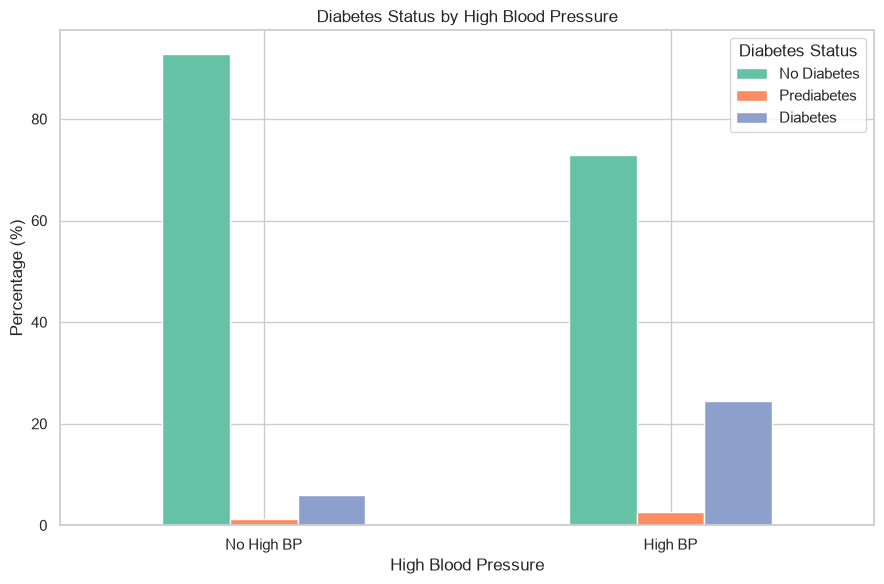

In [25]:
bp_diabetes.plot(
    kind="bar",
    figsize=(9, 6),
    color=["#66c2a5", "#fc8d62", "#8da0cb"]
)

plt.title("Diabetes Status by High Blood Pressure")
plt.xlabel("High Blood Pressure")
plt.ylabel("Percentage (%)")

plt.xticks(
    [0, 1],
    ["No High BP", "High BP"],
    rotation=0
)

plt.legend(
    title="Diabetes Status",
    labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.tight_layout()
plt.show()

## Interpretation

The normalized cross-tabulation compares the percentage distribution of diabetes status between individuals with and without high blood pressure.

If the diabetes percentage is substantially higher among individuals with high blood pressure, this suggests an association between high blood pressure and diabetes status.

This does not mean that high blood pressure causes diabetes. It means that the two variables are associated within this dataset.

In [26]:
chol_diabetes = pd.crosstab(
    df["HighChol"],
    df["Diabetes_012"],
    normalize="index"
) * 100

chol_diabetes

Diabetes_012,0.00,1.00,2.00
HighChol,,,
0.00,90.82,1.20,7.98
1.00,75.31,2.67,22.01


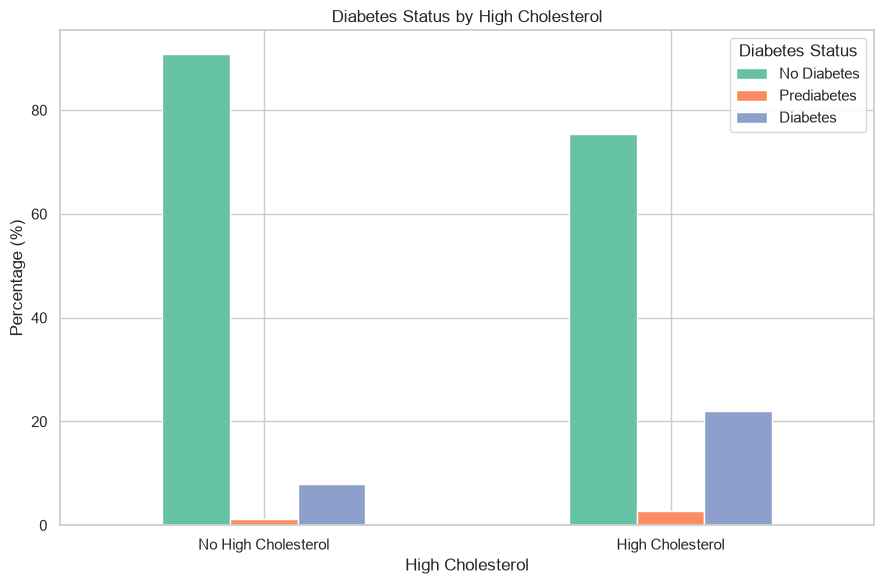

In [27]:
chol_diabetes.plot(
    kind="bar",
    figsize=(9, 6),
    color=["#66c2a5", "#fc8d62", "#8da0cb"]
)

plt.title("Diabetes Status by High Cholesterol")
plt.xlabel("High Cholesterol")
plt.ylabel("Percentage (%)")

plt.xticks(
    [0, 1],
    ["No High Cholesterol", "High Cholesterol"],
    rotation=0
)

plt.legend(
    title="Diabetes Status",
    labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.tight_layout()
plt.show()

In [28]:
activity_diabetes = pd.crosstab(
    df["PhysActivity"],
    df["Diabetes_012"],
    normalize="index"
) * 100

activity_diabetes

Diabetes_012,0.00,1.00,2.00
PhysActivity,,,
0.00,76.44,2.41,21.14
1.00,86.75,1.64,11.61


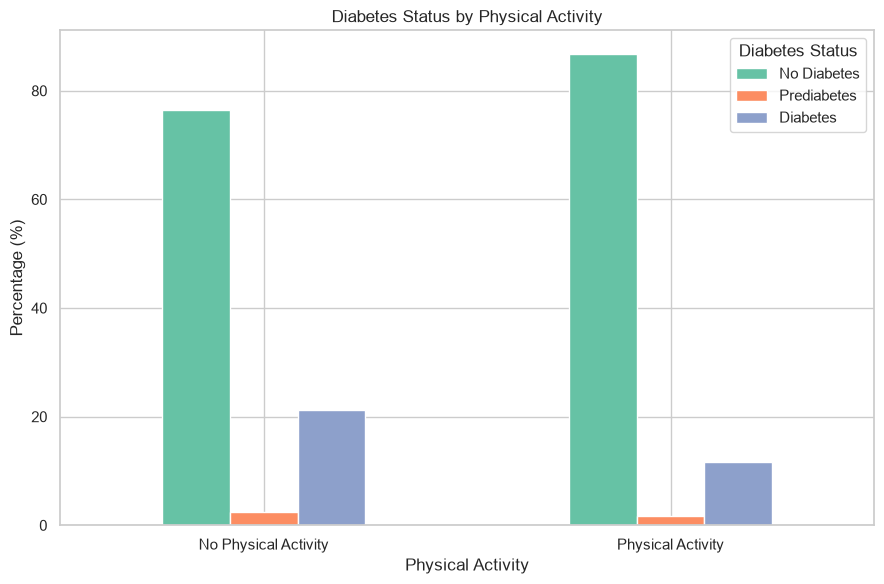

In [29]:
activity_diabetes.plot(
    kind="bar",
    figsize=(9, 6),
    color=["#66c2a5", "#fc8d62", "#8da0cb"]
)

plt.title("Diabetes Status by Physical Activity")
plt.xlabel("Physical Activity")
plt.ylabel("Percentage (%)")

plt.xticks(
    [0, 1],
    ["No Physical Activity", "Physical Activity"],
    rotation=0
)

plt.legend(
    title="Diabetes Status",
    labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.tight_layout()
plt.show()

In [30]:
smoking_diabetes = pd.crosstab(
    df["Smoker"],
    df["Diabetes_012"],
    normalize="index"
) * 100

smoking_diabetes

Diabetes_012,0.00,1.00,2.00
Smoker,,,
0.00,86.28,1.66,12.06
1.00,81.68,2.03,16.29


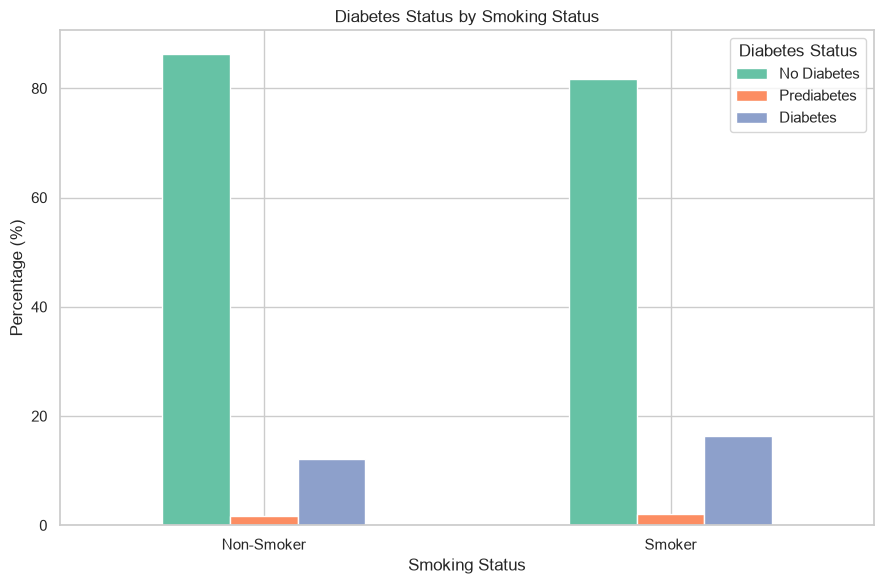

In [31]:
smoking_diabetes.plot(
    kind="bar",
    figsize=(9, 6),
    color=["#66c2a5", "#fc8d62", "#8da0cb"]
)

plt.title("Diabetes Status by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Percentage (%)")

plt.xticks(
    [0, 1],
    ["Non-Smoker", "Smoker"],
    rotation=0
)

plt.legend(
    title="Diabetes Status",
    labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.tight_layout()
plt.show()

In [32]:
heart_diabetes = pd.crosstab(
    df["HeartDiseaseorAttack"],
    df["Diabetes_012"],
    normalize="index"
) * 100

heart_diabetes

Diabetes_012,0.00,1.00,2.00
HeartDiseaseorAttack,,,
0.00,86.32,1.73,11.95
1.00,64.25,2.78,32.97


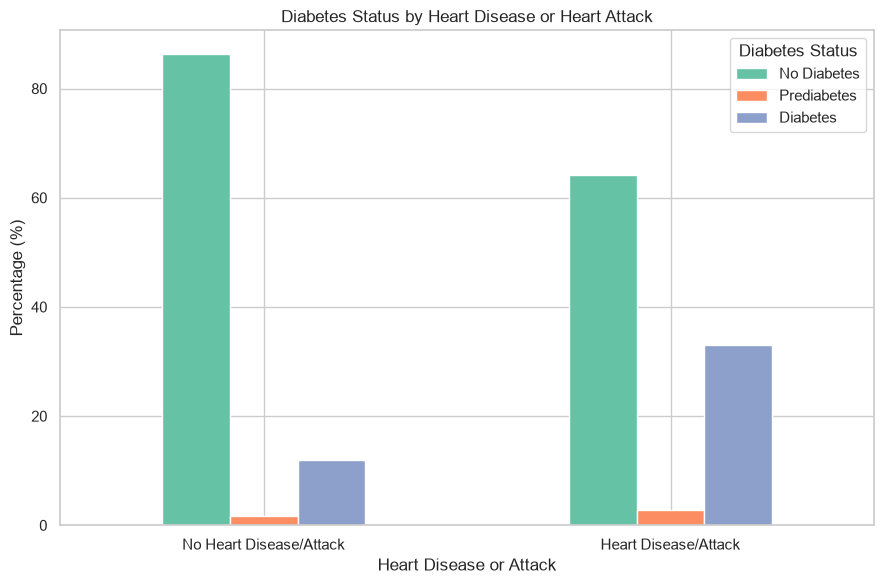

In [33]:
heart_diabetes.plot(
    kind="bar",
    figsize=(9, 6),
    color=["#66c2a5", "#fc8d62", "#8da0cb"]
)

plt.title("Diabetes Status by Heart Disease or Heart Attack")
plt.xlabel("Heart Disease or Attack")
plt.ylabel("Percentage (%)")

plt.xticks(
    [0, 1],
    ["No Heart Disease/Attack", "Heart Disease/Attack"],
    rotation=0
)

plt.legend(
    title="Diabetes Status",
    labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.tight_layout()
plt.show()

# 8. Mental and Physical Health

`MentHlth` measures the number of days during the previous 30 days when mental health was not good.

`PhysHlth` measures the number of days during the previous 30 days when physical health was not good.

Histograms are appropriate because these variables represent numerical counts of days.

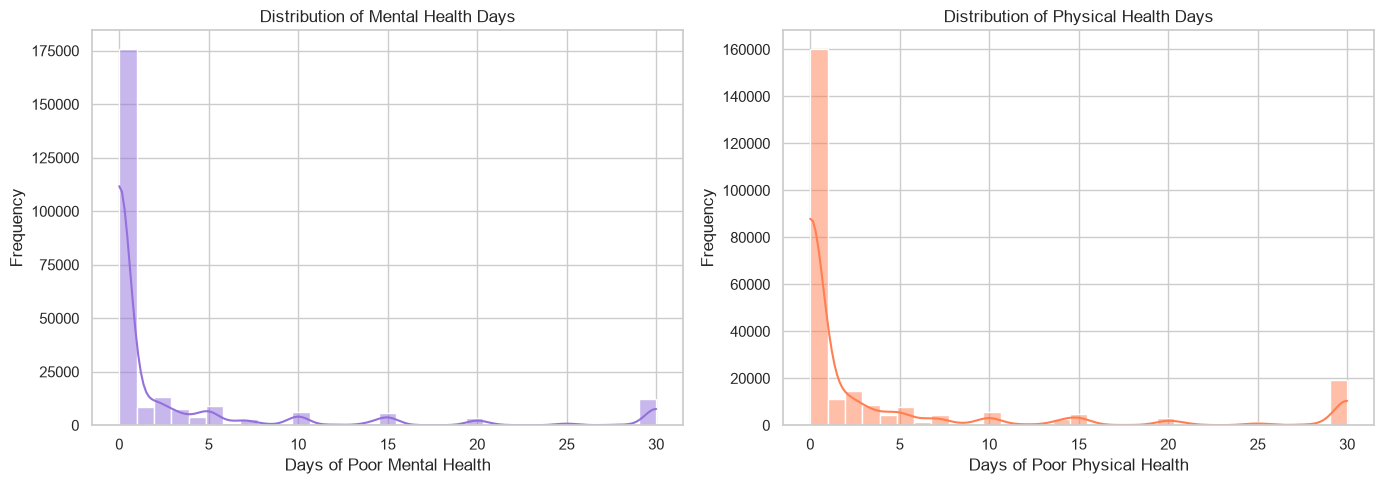

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="MentHlth",
    bins=31,
    kde=True,
    ax=axes[0],
    color="mediumpurple"
)

axes[0].set_title("Distribution of Mental Health Days")
axes[0].set_xlabel("Days of Poor Mental Health")
axes[0].set_ylabel("Frequency")

sns.histplot(
    data=df,
    x="PhysHlth",
    bins=31,
    kde=True,
    ax=axes[1],
    color="coral"
)

axes[1].set_title("Distribution of Physical Health Days")
axes[1].set_xlabel("Days of Poor Physical Health")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 9. Relationship Analysis

Correlation analysis can help identify variables that move together.

However, correlation must be interpreted carefully in this dataset because many variables are binary or ordinal rather than continuous.

Correlation does not imply causation.

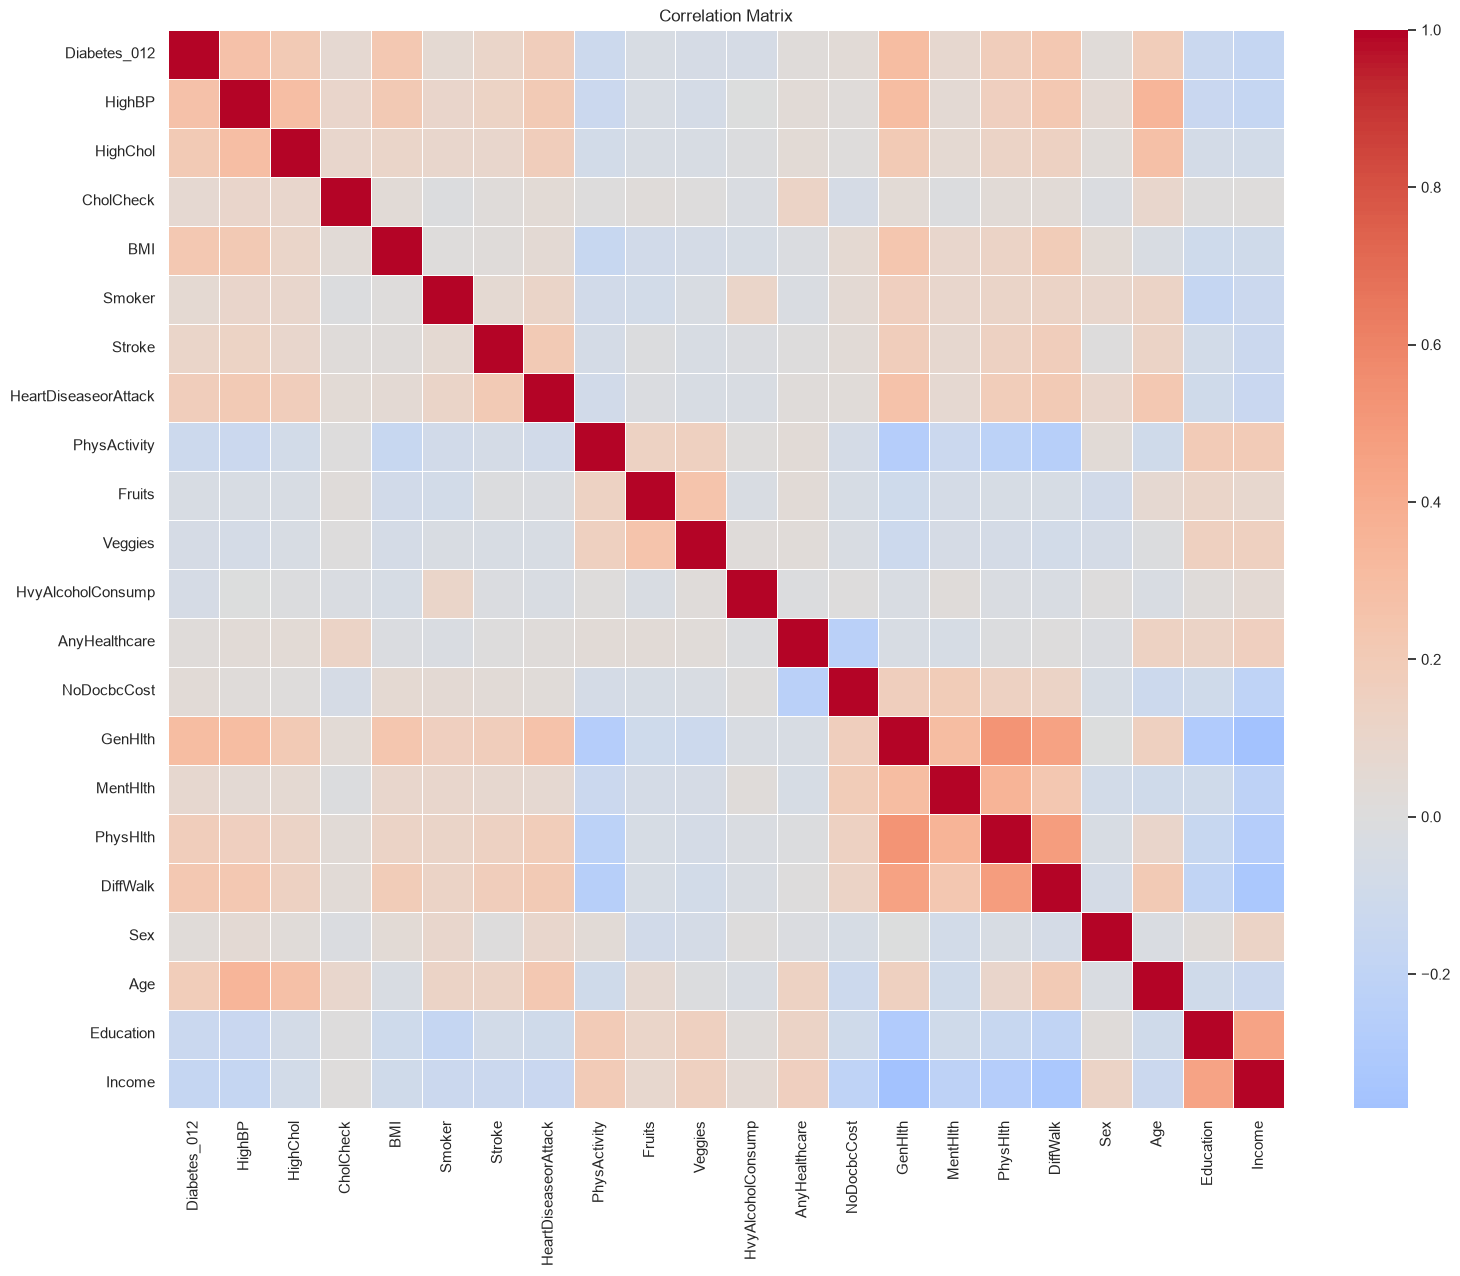

In [35]:
correlation_matrix = df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

In [36]:
diabetes_correlations = (
    df.corr()["Diabetes_012"]
    .drop("Diabetes_012")
    .sort_values(ascending=False)
)

diabetes_correlations

GenHlth                 0.30
HighBP                  0.27
BMI                     0.22
DiffWalk                0.22
HighChol                0.21
Age                     0.19
HeartDiseaseorAttack    0.18
PhysHlth                0.18
Stroke                  0.11
MentHlth                0.07
CholCheck               0.07
Smoker                  0.06
NoDocbcCost             0.04
Sex                     0.03
AnyHealthcare           0.02
Fruits                 -0.04
HvyAlcoholConsump      -0.06
Veggies                -0.06
PhysActivity           -0.12
Education              -0.13
Income                 -0.17
Name: Diabetes_012, dtype: float64

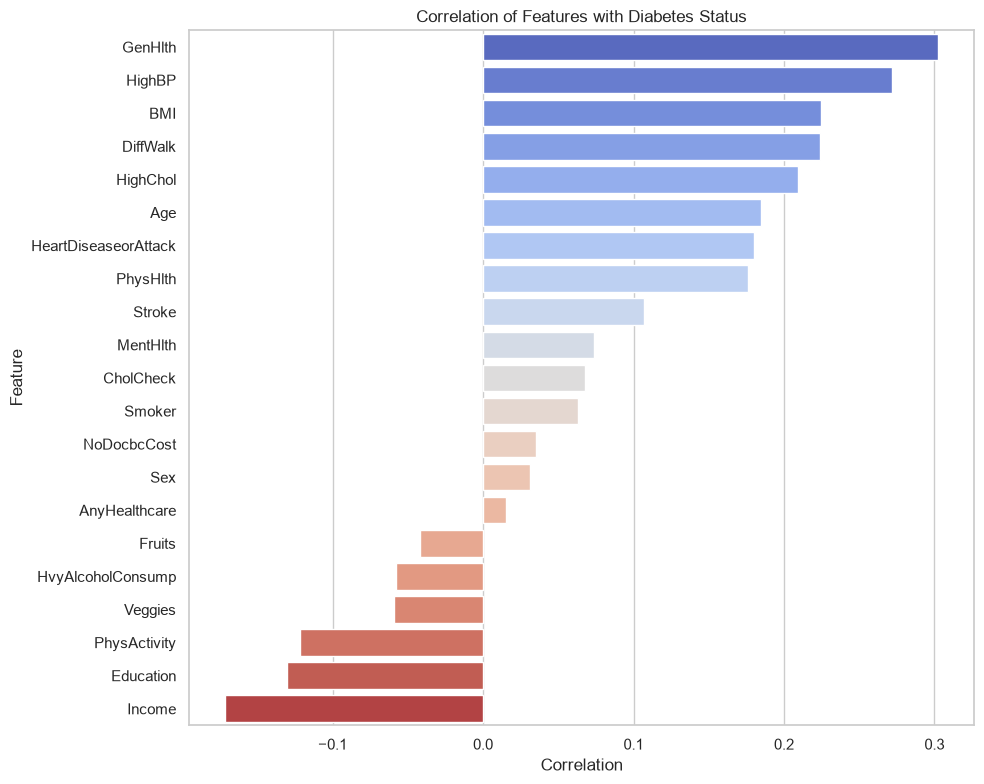

In [37]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x=diabetes_correlations.values,
    y=diabetes_correlations.index,
    hue=diabetes_correlations.index,
    palette="coolwarm",
    legend=False
)

plt.title("Correlation of Features with Diabetes Status")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 10. Group-Wise Analysis

Another way to examine relationships is to compare the average values of features across the three diabetes groups.

This can help identify variables that differ between people with no diabetes, prediabetes, and diabetes.

In [38]:
summary_by_diabetes = (
    df.groupby("Diabetes_012")
    .mean(numeric_only=True)
    .T
)

summary_by_diabetes.columns = [
    "No Diabetes",
    "Prediabetes",
    "Diabetes"
]

summary_by_diabetes

,No Diabetes,Prediabetes,Diabetes
HighBP,0.37,0.63,0.75
HighChol,0.38,0.62,0.67
CholCheck,0.96,0.99,0.99
BMI,27.74,30.72,31.94
Smoker,0.43,0.49,0.52
Stroke,0.03,0.06,0.09
HeartDiseaseorAttack,0.07,0.14,0.22
PhysActivity,0.78,0.68,0.63
Fruits,0.64,0.60,0.59
Veggies,0.82,0.77,0.76


# 11. Feature Engineering

Feature engineering involves creating new variables from existing data.

One useful feature is a BMI category.

This makes BMI easier to interpret and may also provide a useful feature for future predictive modeling.

In [39]:
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

df["BMI_Category"].value_counts()

BMI_Category
Overweight     91176
Normal         86099
Obese          73278
Underweight     3127
Name: count, dtype: int64

In [40]:
bmi_diabetes_rate = (
    df.groupby(
        "BMI_Category",
        observed=True
    )["Diabetes_012"]
    .apply(lambda x: (x > 0).mean() * 100)
)

bmi_diabetes_rate

BMI_Category
Underweight    6.30
Normal         7.32
Overweight    14.47
Obese         27.68
Name: Diabetes_012, dtype: float64

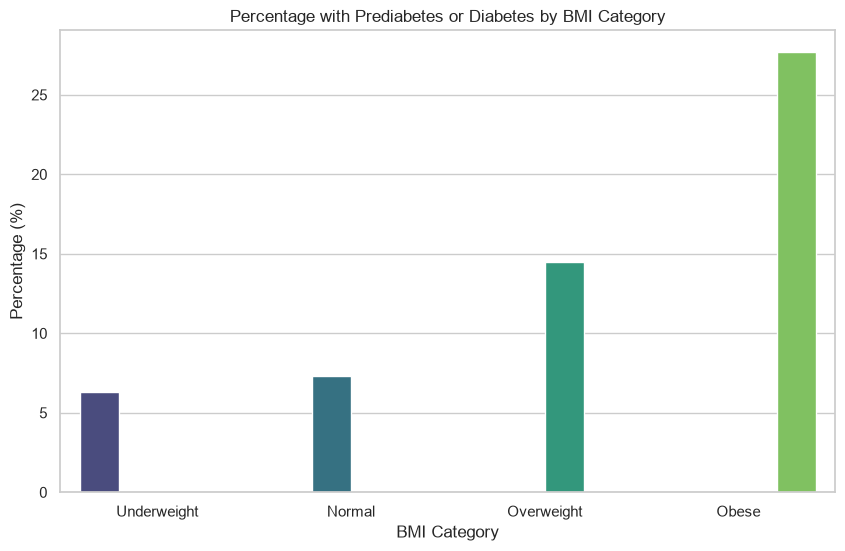

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=bmi_diabetes_rate.index,
    y=bmi_diabetes_rate.values,
    hue=bmi_diabetes_rate.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Percentage with Prediabetes or Diabetes "
    "by BMI Category"
)

plt.xlabel("BMI Category")
plt.ylabel("Percentage (%)")

plt.show()

## 11.1 Additional Features That Could Be Created

Several additional features could be created from the existing variables.

### Poor Physical Health Indicator

A binary variable could identify respondents reporting 14 or more days of poor physical health.

### Poor Mental Health Indicator

A binary variable could identify respondents reporting 14 or more days of poor mental health.

### Cardiovascular Risk Count

A combined feature could count the presence of high blood pressure, high cholesterol, heart disease, and stroke.

### Healthy Lifestyle Score

A lifestyle score could combine physical activity, fruit consumption, vegetable consumption, non-smoking, and non-heavy alcohol consumption.

These features could be evaluated during future predictive modeling to determine whether they improve model performance.

In [42]:
df["High_PhysHlth"] = (
    df["PhysHlth"] >= 14
).astype(int)

df["High_MentHlth"] = (
    df["MentHlth"] >= 14
).astype(int)

df["Cardiovascular_Risk_Count"] = (
    df["HighBP"] +
    df["HighChol"] +
    df["HeartDiseaseorAttack"] +
    df["Stroke"]
)

df["Healthy_Lifestyle_Score"] = (
    df["PhysActivity"] +
    df["Fruits"] +
    df["Veggies"] +
    (1 - df["Smoker"]) +
    (1 - df["HvyAlcoholConsump"])
)

df[
    [
        "High_PhysHlth",
        "High_MentHlth",
        "Cardiovascular_Risk_Count",
        "Healthy_Lifestyle_Score"
    ]
].head()

,High_PhysHlth,High_MentHlth,Cardiovascular_Risk_Count,Healthy_Lifestyle_Score
0,1,1,2.00,2.00
1,0,0,0.00,2.00
2,1,1,2.00,3.00
3,0,0,1.00,5.00
4,0,0,2.00,5.00


# 12. Exceptional Analysis — Principal Component Analysis

Principal Component Analysis (PCA) is a dimensionality-reduction technique.

The dataset contains many variables, so PCA can reduce the feature space to two dimensions and allow us to visualize the overall structure of the observations.

The purpose of PCA in this analysis is not to prove that the groups are different. Instead, it provides another way to investigate whether individuals with different diabetes statuses appear to form distinguishable patterns in the feature space.

In [43]:
# Select only the original numeric features for PCA
pca_features = [
    col for col in df.columns
    if col not in ["Diabetes_012", "BMI_Category"]
]

print("PCA features:")
print(pca_features)

PCA features:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'High_PhysHlth', 'High_MentHlth', 'Cardiovascular_Risk_Count', 'Healthy_Lifestyle_Score']


In [44]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[pca_features])

print("Features standardized successfully.")
print("Shape of standardized data:", X_scaled.shape)

Features standardized successfully.
Shape of standardized data: (253680, 25)


In [45]:
pca = PCA(n_components=2)

X_pca_2d = pca.fit_transform(X_scaled)

pc1_variance = pca.explained_variance_ratio_[0] * 100
pc2_variance = pca.explained_variance_ratio_[1] * 100
total_variance = pc1_variance + pc2_variance

print(f"PC1 explains {pc1_variance:.2f}% of the variance.")
print(f"PC2 explains {pc2_variance:.2f}% of the variance.")
print(f"Combined variance explained: {total_variance:.2f}%")

PC1 explains 18.98% of the variance.
PC2 explains 9.65% of the variance.
Combined variance explained: 28.63%


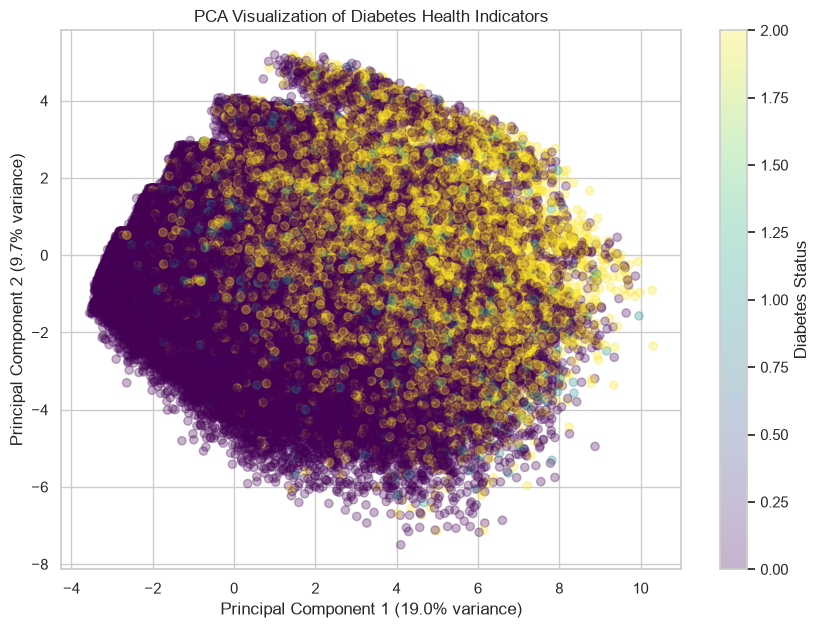

In [46]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=df["Diabetes_012"],
    cmap="viridis",
    alpha=0.3
)

plt.xlabel(f"Principal Component 1 ({pc1_variance:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pc2_variance:.1f}% variance)")

plt.title(
    "PCA Visualization of Diabetes Health Indicators"
)

plt.colorbar(
    scatter,
    label="Diabetes Status"
)

plt.show()

## PCA Interpretation

PCA provides a two-dimensional representation of the original feature space.

If observations belonging to different diabetes classes form clearly separated clusters, this could indicate that the available features contain useful information for distinguishing diabetes status.

If the groups overlap substantially, it suggests that diabetes status is not easily separated using only the first two principal components.

PCA is primarily being used here as a visualization and dimensionality-reduction technique. It does not by itself determine which individual variables are the most important predictors.

# 13. Key Findings

Based on the exploratory analysis, several areas are important for further investigation.

### 1. Diabetes Status

The target variable contains three classes: no diabetes, prediabetes, and diabetes. The distribution of these classes should be considered when developing a predictive model.

### 2. High Blood Pressure

The relationship between high blood pressure and diabetes status is important because the percentage distribution of diabetes may differ between people with and without high blood pressure.

### 3. High Cholesterol

High cholesterol may also be associated with diabetes status and should be considered as a potential predictive feature.

### 4. BMI

BMI provides an important numerical health measurement. Differences in BMI across diabetes categories may make BMI useful for prediction.

### 5. General Health

Self-reported general health may differ across diabetes groups and can provide information about overall health status.

### 6. Age

Diabetes status should be examined across age categories because the distribution of diabetes may change as age category increases.

### 7. Heart Disease and Stroke

Heart disease and stroke may show relationships with diabetes and may provide additional predictive information.

### 8. Physical Activity

Physical activity provides an important lifestyle measure and may help distinguish individuals across diabetes categories.

### 9. Mental and Physical Health

The number of poor mental and physical health days may provide additional information about overall health.

### 10. Education and Income

Socioeconomic characteristics may reveal differences between diabetes groups and may provide useful information for predictive modeling.

All of these relationships should be interpreted as associations rather than evidence of causation.

# 14. Conclusion

This exploratory data analysis examined the relationship between lifestyle, health conditions, demographic characteristics, and diabetes status using the BRFSS 2015 Diabetes Health Indicators dataset.

The analysis investigated the distribution and quality of the data, descriptive statistics, important health and lifestyle variables, relationships between features, and relationships between the features and the target variable.

Variables such as high blood pressure, high cholesterol, BMI, general health, age, heart disease, stroke, physical activity, and physical health are particularly important areas for further investigation.

The analysis also demonstrated how new features can be created from existing variables. BMI categories, poor-health indicators, cardiovascular risk counts, and a healthy lifestyle score may provide additional information for future modeling.

The target variable contains three diabetes classifications, so future machine-learning models should be evaluated using classification metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. Accuracy should not be considered by itself if the diabetes classes are imbalanced.

Finally, PCA was used as an additional analysis technique to visualize the overall structure of the dataset.

The EDA identifies associations and patterns but does not establish causation. The next step would be to use statistical testing and machine-learning classification models to determine which features are most useful for predicting diabetes status.

In [47]:
df.to_csv(
    "diabetes_012_health_indicators_BRFSS2015_eda.csv",
    index=False
)

print("EDA dataset saved successfully.")

EDA dataset saved successfully.
